In [1]:
import numpy as np
import matplotlib.pyplot as plt
from grid import (
    make_radial_grid,
    cell_centers,
    shell_volumes,
    log_cell_centers,
    log_shell_volumes,
)
from initial_conditions import (
    nfw_dimensionless,
    truncated_nfw_dimensionless,
    enclosed_mass,
    shell_mass,
    hydrostatic_u_from_rho,
)
from residual import (
    hydrostatic_residual,
    hydrostatic_terms_and_scale,
    energy_residual,
    energy_terms,
    residual,
)
from state import state_from_unknowns
from constants import FLOAT_DTYPE
from jacobian import *
from residual import unpack_unknowns

In [2]:
r_inner = 0.0
r_first = 0.001
r_max = 70.0
N_shell = 200

In [3]:
r_edge = make_radial_grid(r_first, r_max, N_shell)
r = cell_centers(r_edge)
V = shell_volumes(r_edge)

In [4]:
ln_r_edge = np.empty(N_shell + 1, dtype=FLOAT_DTYPE)
ln_r_edge[0] = -np.inf if r_inner == 0.0 else np.log(r_inner)
ln_r_edge[1:] = np.log(r_edge[1:])

ln_r = log_cell_centers(ln_r_edge)
ln_V = log_shell_volumes(ln_r_edge)

In [5]:
r_edge.dtype, r.dtype, V.dtype, ln_r.dtype, ln_V.dtype

(dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'))

In [6]:
rho = nfw_dimensionless(r)
dm = shell_mass(rho, V)
M_edge = enclosed_mass(dm)
u = hydrostatic_u_from_rho(r_edge, rho, M_edge, u_outer=0.01)

In [7]:
rho.dtype, dm.dtype, M_edge.dtype, u.dtype

(dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'))

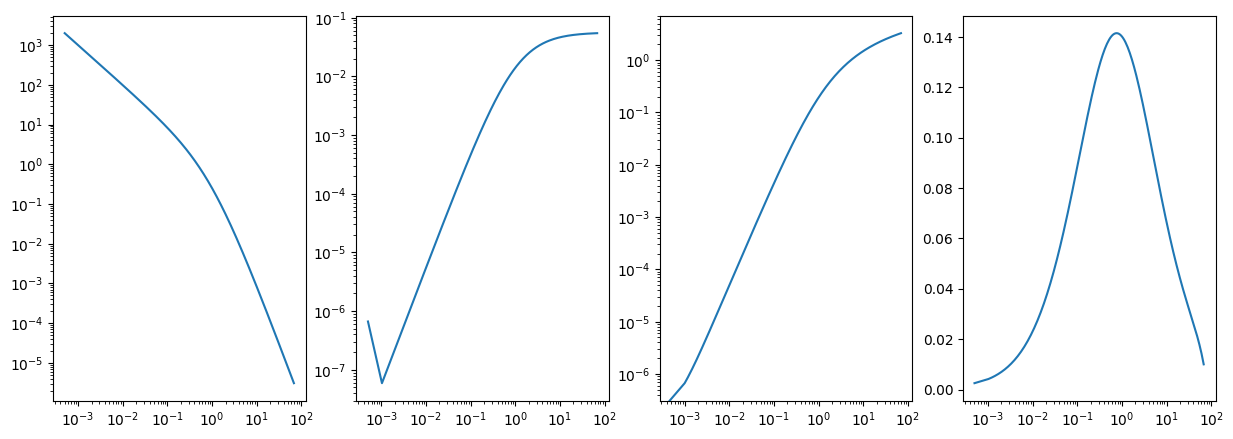

In [8]:
fig, ax = plt.subplots(1, 4, figsize=(15, 5), sharex="all")
ax[0].plot(r, rho)
ax[1].plot(r, dm)
ax[2].plot(r_edge, M_edge)
ax[3].plot(r, u)

ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[1].set_yscale("log")
ax[2].set_yscale("log")

In [9]:
sigma_over_m = FLOAT_DTYPE(0.3)
C = FLOAT_DTYPE(0.8)
alpha = FLOAT_DTYPE(1.0)

In [10]:
point = np.concatenate((ln_r_edge[1:-1], u))

ln_r_test, u_test = unpack_unknowns(point, r_inner, r_max, N_shell)

state_test = state_from_unknowns(
    ln_r_test,
    u_test,
    dm,
    sigma_over_m,
    C,
    alpha,
)

v_old = state_test["v"]
ln_r_edge_old = state_test["ln_r_edge"]
u_old = state_test["u"]
dt = 0.001

jac = jacobian(
    state_test,
    M_edge,
    v_old,
    alpha,
    dm,
    dt,
    N_shell,
)

In [11]:
func = lambda x: residual(
    x,
    ln_r_edge_old,
    u_old,
    dt,
    dm,
    M_edge,
    sigma_over_m,
    C,
    alpha,
    r_inner,
    r_max,
    N_shell,
)

In [12]:
def numerical_jacobian(F, x, step):
    f0 = F(x)
    J = np.empty((len(f0), len(x)), dtype=np.float64)

    for j in range(len(x)):
        h = step

        x_plus = x.copy()
        x_minus = x.copy()

        x_plus[j] += h
        x_minus[j] -= h

        J[:, j] = (F(x_plus) - F(x_minus)) / (2.0 * h)

    return J

In [18]:
jac_num = numerical_jacobian(func, point, 1e-5)

In [19]:
a = 0
b = N_shell - 1
c = 0
d = N_shell - 1
rel_err = np.abs(jac[a:b, c:d] - jac_num[a:b, c:d]) / np.maximum(
    1.0, np.maximum(np.abs(jac[a:b, c:d]), np.abs(jac_num[a:b, c:d]))
)
np.max(rel_err)

2.8555943004638858e-08

In [20]:
a = 0
b = N_shell - 1
c = N_shell - 1
d = 2 * N_shell
rel_err = np.abs(jac[a:b, c:d] - jac_num[a:b, c:d]) / np.maximum(
    1.0, np.maximum(np.abs(jac[a:b, c:d]), np.abs(jac_num[a:b, c:d]))
)
np.max(rel_err)

5.032950711638302e-06

In [21]:
a = N_shell - 1
b = 2 * N_shell
c = 0
d = N_shell - 1
rel_err = np.abs(jac[a:b, c:d] - jac_num[a:b, c:d]) / np.maximum(
    1.0, np.maximum(np.abs(jac[a:b, c:d]), np.abs(jac_num[a:b, c:d]))
)
np.max(rel_err)

3.193922648875699e-08

In [22]:
a = N_shell - 1
b = 2 * N_shell
c = N_shell - 1
d = 2 * N_shell
rel_err = np.abs(jac[a:b, c:d] - jac_num[a:b, c:d]) / np.maximum(
    1.0, np.maximum(np.abs(jac[a:b, c:d]), np.abs(jac_num[a:b, c:d]))
)
np.max(rel_err)

9.545672638099012e-07